Lab 2: Fashion MNIST Classification with Deep Neural Network

Step 1: Loading and Preprocessing Fashion MNIST Data


100%|█████████████████████████████████████████████████████████████████████████████| 26.4M/26.4M [00:12<00:00, 2.08MB/s]
100%|█████████████████████████████████████████████████████████████████████████████| 29.5k/29.5k [00:00<00:00, 68.6kB/s]
100%|██████████████████████████████████████████████████████████████████████████████| 4.42M/4.42M [00:20<00:00, 212kB/s]
100%|█████████████████████████████████████████████████████████████████████████████████████| 5.15k/5.15k [00:00<?, ?B/s]


Training samples: 60000
Test samples: 10000
Batch size: 128
Number of classes: 10
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

Sample images saved as 'fashion_mnist_samples.png'


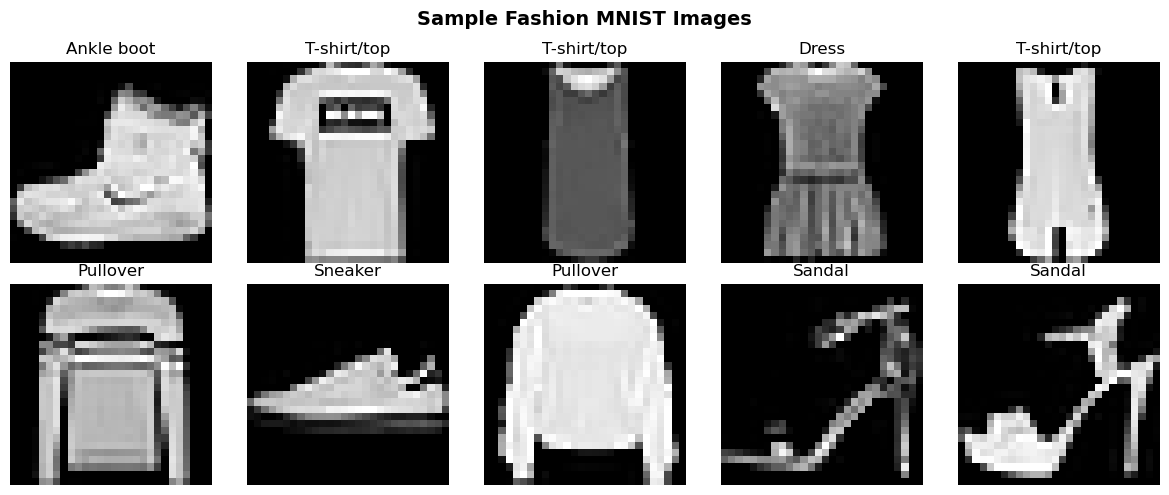


Step 2: Building Deep Feedforward Neural Network
DeepFashionNet(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=128, bias=True)
  (fc4): Linear(in_features=128, out_features=10, bias=True)
  (activation): ReLU()
)

Total parameters: 567,434
Trainable parameters: 567,434

Step 3: Defining Loss Function and Optimizer
Loss Function: Cross Entropy Loss
Optimizer: Adam
Learning Rate: 0.001

Step 4: Training the Model
Total epochs: 10

Epoch [1/10], Step [100/469], Loss: 0.5818
Epoch [1/10], Step [200/469], Loss: 0.5171
Epoch [1/10], Step [300/469], Loss: 0.5387
Epoch [1/10], Step [400/469], Loss: 0.4491
Epoch [1/10] - Loss: 0.5189, Accuracy: 80.94%, Time: 27.67s
------------------------------------------------------------
Epoch [2/10], Step [100/469], Loss: 0.3504
Epoch [2/10], Step [200/469], Loss: 0.3007
Epoch [2/10], Step [300/469], Loss: 0.5094
Epoch [2/10], Step [

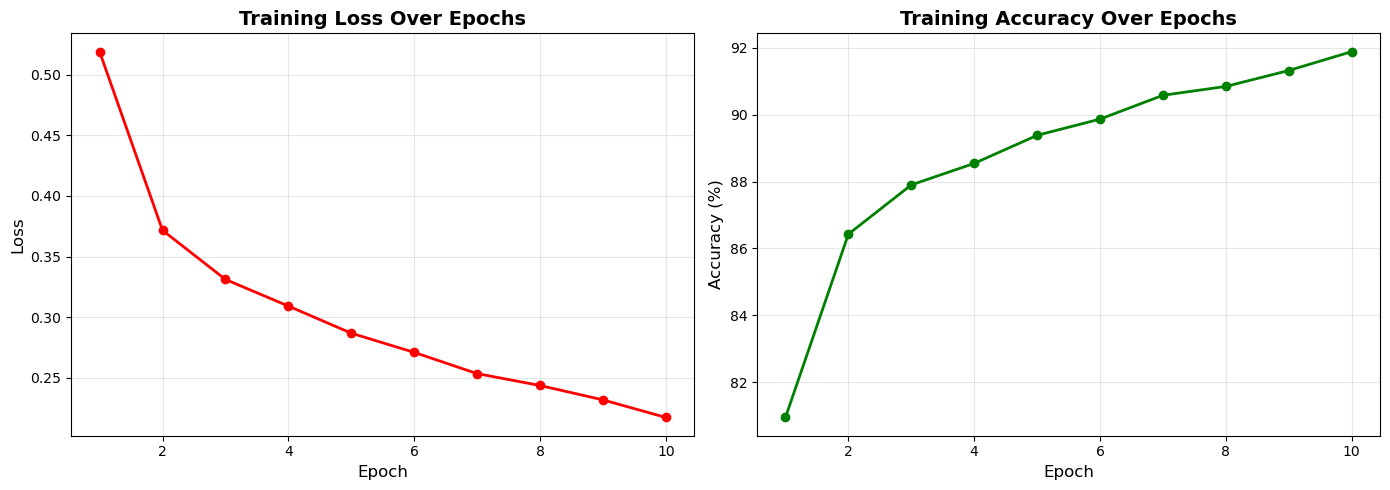

Confusion matrix saved as 'confusion_matrix.png'


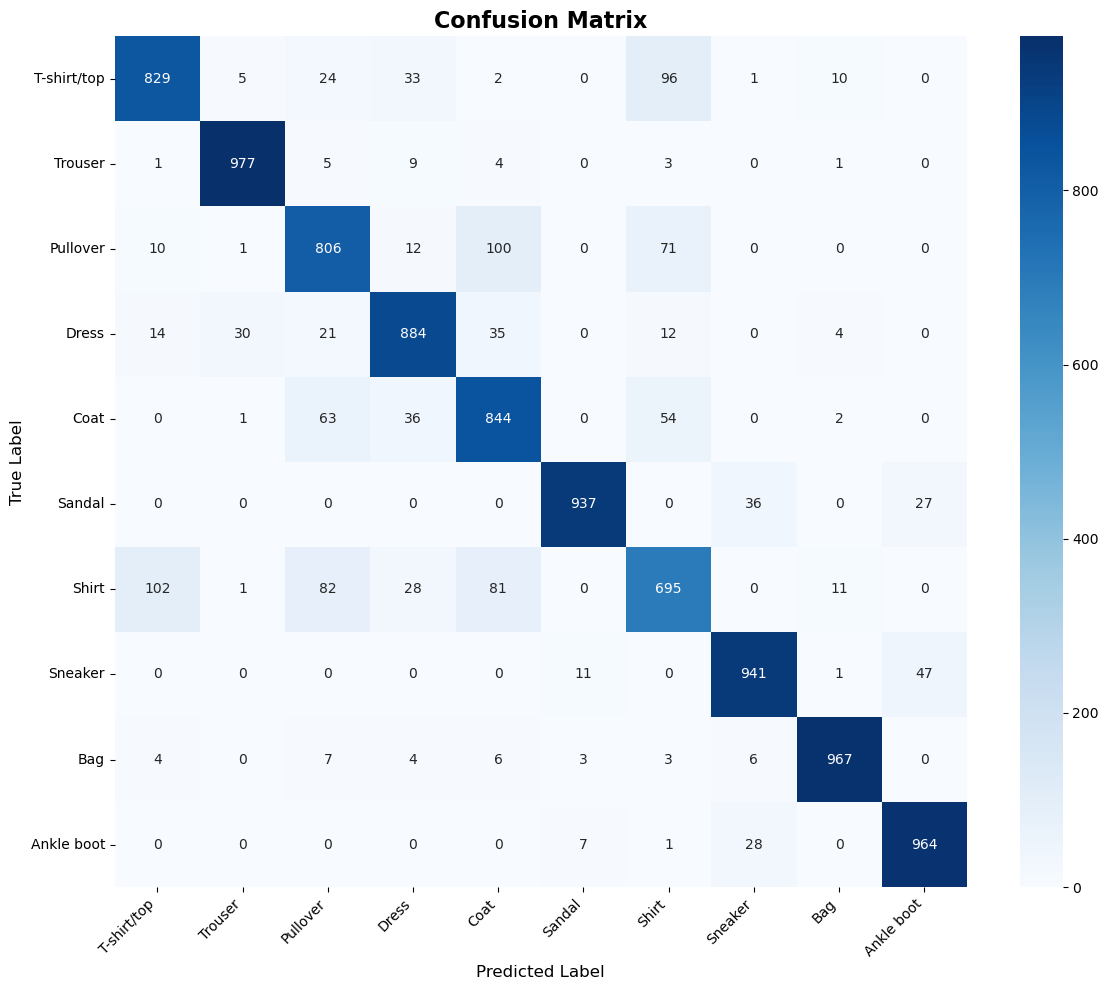


Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.86      0.83      0.85      1000
     Trouser       0.96      0.98      0.97      1000
    Pullover       0.80      0.81      0.80      1000
       Dress       0.88      0.88      0.88      1000
        Coat       0.79      0.84      0.81      1000
      Sandal       0.98      0.94      0.96      1000
       Shirt       0.74      0.69      0.72      1000
     Sneaker       0.93      0.94      0.94      1000
         Bag       0.97      0.97      0.97      1000
  Ankle boot       0.93      0.96      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000


ADVANCED TASK 2: Activation Function Comparison

Training with RELU activation
Step 4: Training the Model
Total epochs: 5

Epoch [1/5], Step [100/469], Loss: 0.4703
Epoch [1/5], Step [200/469], Loss: 0.5661
Epoch [1/

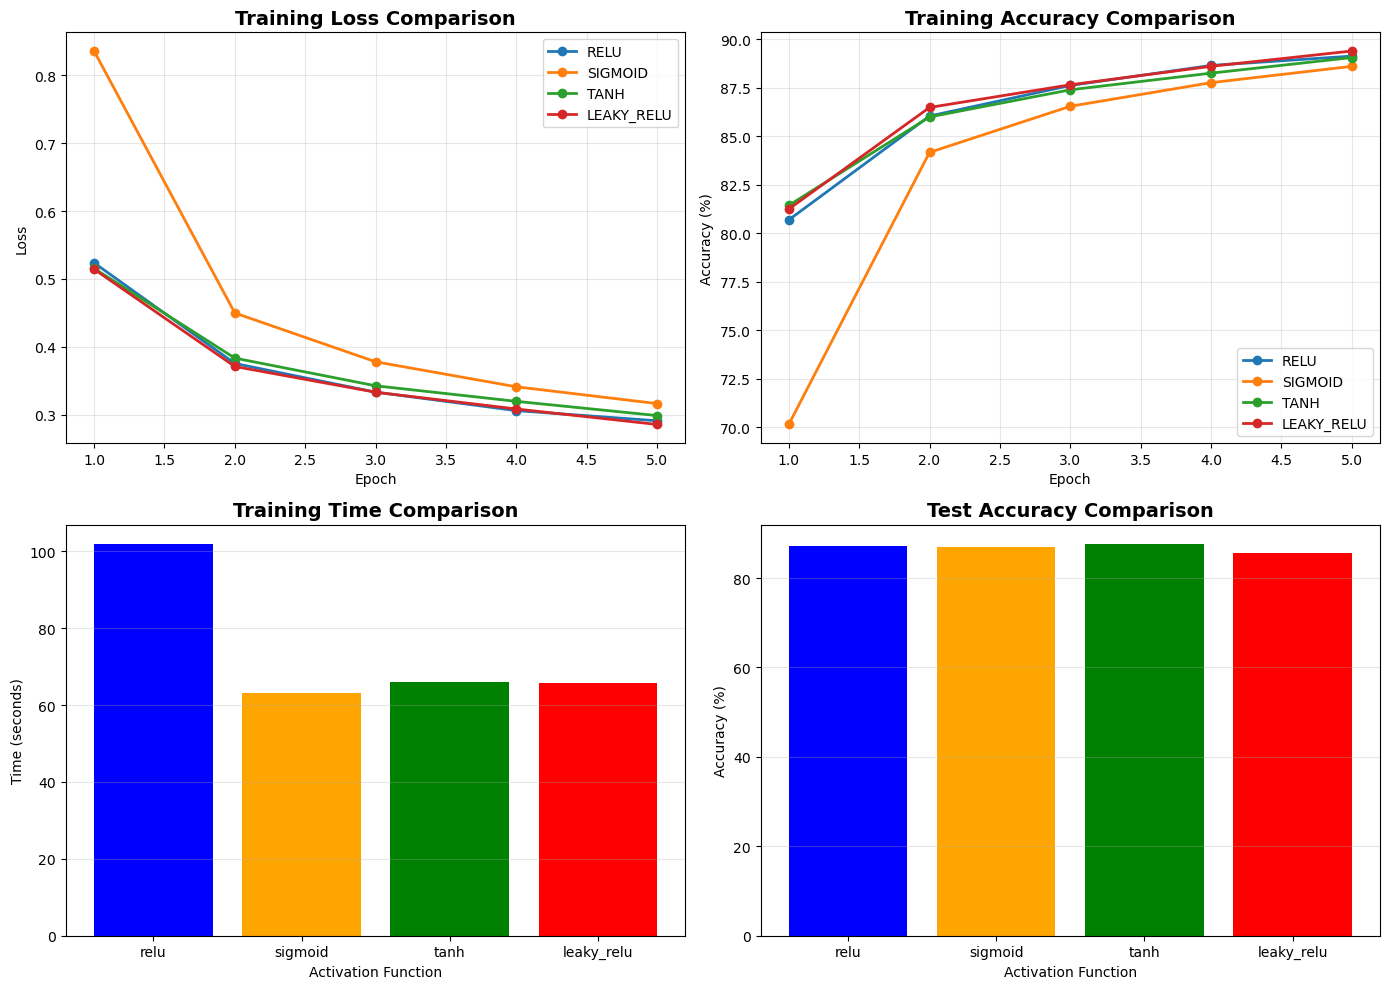


ADVANCED TASK 3: Hidden Layer Visualization
Hidden layer visualization saved as 'hidden_layer_visualization.png'


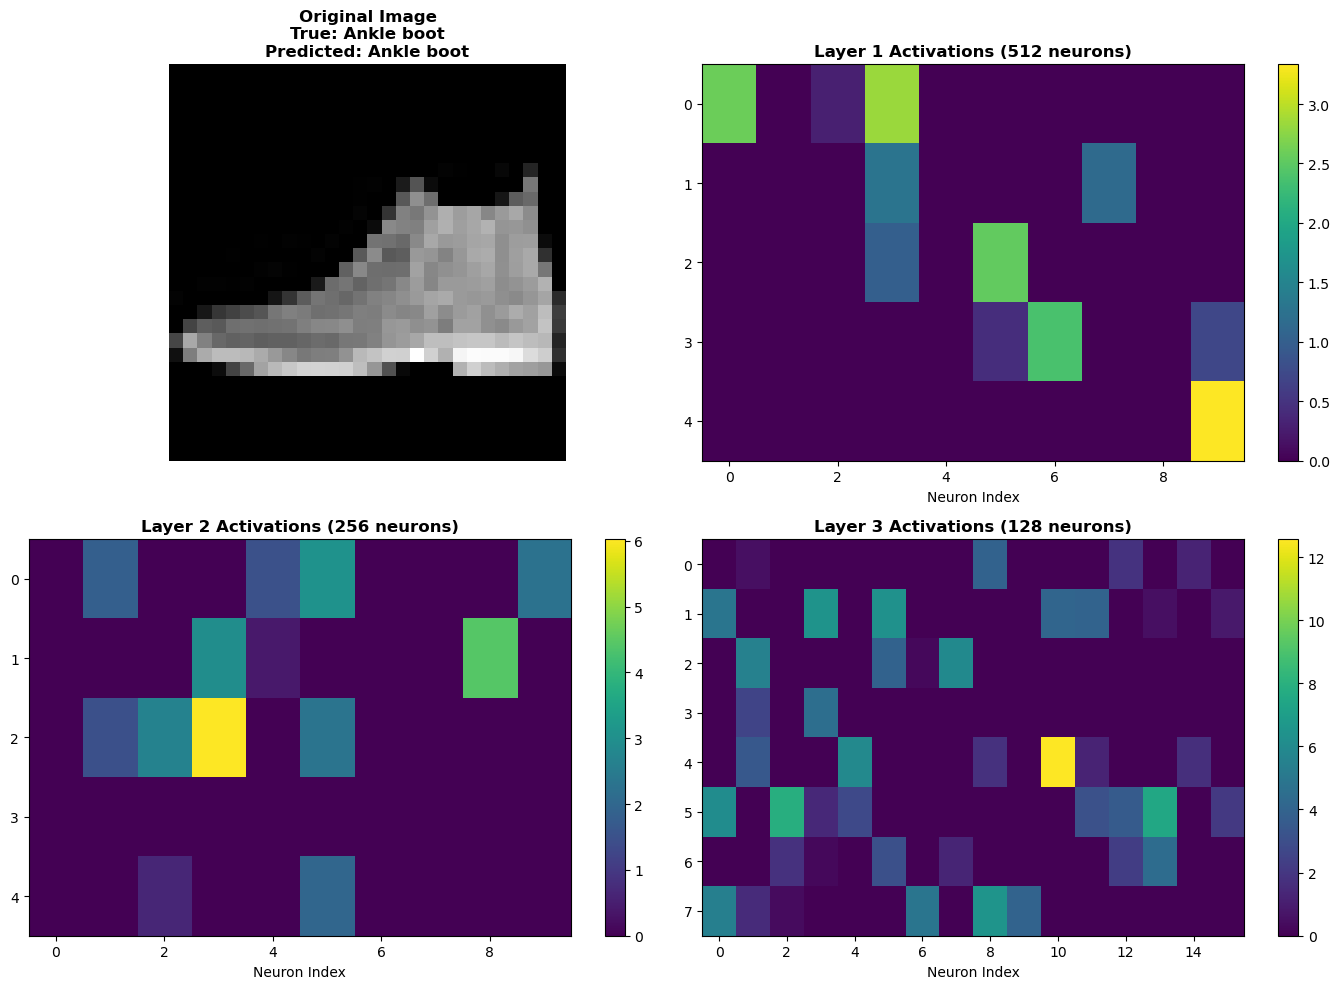

Activation distributions saved as 'activation_distributions.png'


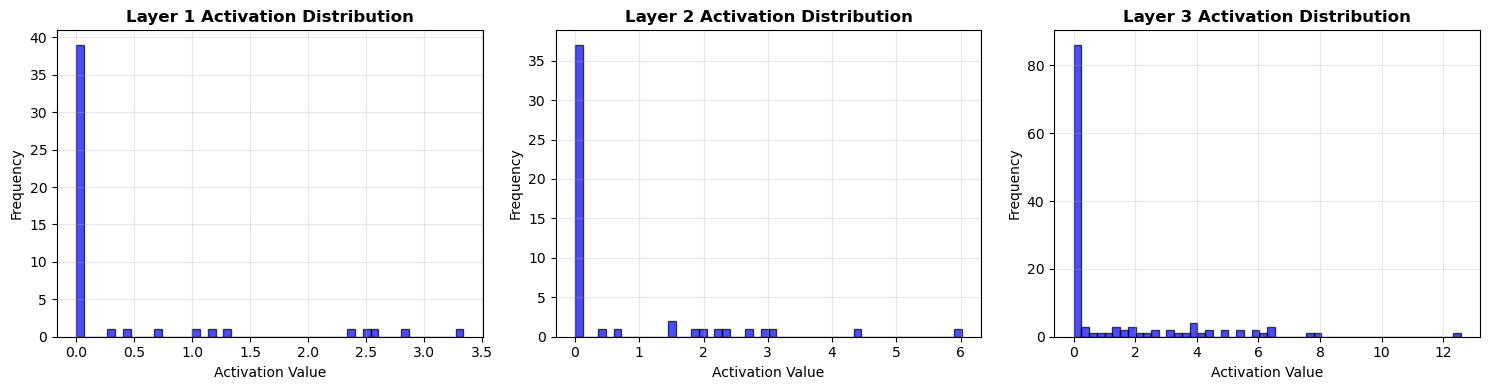


Lab 2 Complete!

Generated Files:
1. fashion_mnist_samples.png
2. training_history.png
3. confusion_matrix.png
4. activation_comparison.png
5. hidden_layer_visualization.png
6. activation_distributions.png


In [6]:

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import time
from collections import defaultdict


torch.manual_seed(42)

print("=" * 80)
print("Lab 2: Fashion MNIST Classification with Deep Neural Network")
print("=" * 80)
print()


# 1. LOAD AND PREPROCESS FASHION MNIST DATA

print("=" * 60)
print("Step 1: Loading and Preprocessing Fashion MNIST Data")
print("=" * 60)

# Define transformations
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert to tensor
    transforms.Normalize((0.5,), (0.5,))  # Normalize to [-1, 1]
])

# Load training and test datasets
train_dataset = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# Create data loaders
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Fashion MNIST class labels
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Batch size: {batch_size}")
print(f"Number of classes: {len(class_names)}")
print(f"Classes: {class_names}")
print()

# Visualize sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i]
    img = img.squeeze().numpy()
    ax.imshow(img, cmap='gray')
    ax.set_title(class_names[label])
    ax.axis('off')
plt.suptitle('Sample Fashion MNIST Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fashion_mnist_samples.png', dpi=300, bbox_inches='tight')
print("Sample images saved as 'fashion_mnist_samples.png'")
plt.show()


# 2. CONSTRUCT DEEP FEEDFORWARD NEURAL NETWORK

print("\n" + "=" * 60)
print("Step 2: Building Deep Feedforward Neural Network")
print("=" * 60)

class DeepFashionNet(nn.Module):
    """
    Deep Feedforward Neural Network for Fashion MNIST
    Architecture:
    - Input: 784 (28x28 flattened)
    - Hidden Layer 1: 512 neurons
    - Hidden Layer 2: 256 neurons
    - Hidden Layer 3: 128 neurons
    - Output: 10 classes
    """
    def __init__(self, activation='relu'):
        super(DeepFashionNet, self).__init__()
        
        # Define layers
        self.fc1 = nn.Linear(28 * 28, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 128)
        self.fc4 = nn.Linear(128, 10)
        
        # Select activation function
        if activation == 'relu':
            self.activation = nn.ReLU()
        elif activation == 'sigmoid':
            self.activation = nn.Sigmoid()
        elif activation == 'tanh':
            self.activation = nn.Tanh()
        elif activation == 'leaky_relu':
            self.activation = nn.LeakyReLU(0.01)
        
        self.activation_name = activation
        
        # Store activations for visualization
        self.hidden_activations = {}
    
    def forward(self, x):
        # Flatten input
        x = x.view(-1, 28 * 28)
        
        # Hidden layer 1
        x = self.fc1(x)
        x = self.activation(x)
        self.hidden_activations['layer1'] = x.detach()
        
        # Hidden layer 2
        x = self.fc2(x)
        x = self.activation(x)
        self.hidden_activations['layer2'] = x.detach()
        
        # Hidden layer 3
        x = self.fc3(x)
        x = self.activation(x)
        self.hidden_activations['layer3'] = x.detach()
        
        # Output layer (no activation - will use with CrossEntropyLoss)
        x = self.fc4(x)
        
        return x

# Create model instance
model = DeepFashionNet(activation='relu')
print(model)
print()

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print()


# 3. DEFINE LOSS AND OPTIMIZER

print("=" * 60)
print("Step 3: Defining Loss Function and Optimizer")
print("=" * 60)

# Cross Entropy Loss (includes softmax)
criterion = nn.CrossEntropyLoss()

# Adam optimizer
learning_rate = 0.001
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

print(f"Loss Function: Cross Entropy Loss")
print(f"Optimizer: Adam")
print(f"Learning Rate: {learning_rate}")
print()


# 4. TRAINING FUNCTION


def train_model(model, train_loader, criterion, optimizer, epochs=10):
    """Train the model and return training history"""
    model.train()
    history = {
        'train_loss': [],
        'train_accuracy': [],
        'epoch_time': []
    }
    
    print("=" * 60)
    print("Step 4: Training the Model")
    print("=" * 60)
    print(f"Total epochs: {epochs}")
    print()
    
    for epoch in range(epochs):
        start_time = time.time()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for batch_idx, (images, labels) in enumerate(train_loader):
            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            # Statistics
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            # Print progress
            if (batch_idx + 1) % 100 == 0:
                print(f'Epoch [{epoch+1}/{epochs}], Step [{batch_idx+1}/{len(train_loader)}], '
                      f'Loss: {loss.item():.4f}')
        
        # Calculate epoch metrics
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100 * correct / total
        epoch_time = time.time() - start_time
        
        history['train_loss'].append(epoch_loss)
        history['train_accuracy'].append(epoch_acc)
        history['epoch_time'].append(epoch_time)
        
        print(f'Epoch [{epoch+1}/{epochs}] - Loss: {epoch_loss:.4f}, '
              f'Accuracy: {epoch_acc:.2f}%, Time: {epoch_time:.2f}s')
        print('-' * 60)
    
    print("\nTraining completed!")
    return history


# 5. EVALUATION FUNCTION


def evaluate_model(model, test_loader):
    """Evaluate the model on test data"""
    model.eval()
    correct = 0
    total = 0
    all_predictions = []
    all_labels = []
    
    print("\n" + "=" * 60)
    print("Step 5: Evaluating Model on Test Data")
    print("=" * 60)
    
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    accuracy = 100 * correct / total
    print(f'Test Accuracy: {accuracy:.2f}%')
    print(f'Correct predictions: {correct}/{total}')
    
    return accuracy, all_predictions, all_labels


# 6. TRAIN THE MODEL


epochs = 10
history = train_model(model, train_loader, criterion, optimizer, epochs)


# 7. EVALUATE THE MODEL


test_accuracy, predictions, labels = evaluate_model(model, test_loader)


# 8. VISUALIZE TRAINING HISTORY


print("\n" + "=" * 60)
print("Generating Training Visualizations")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot training loss
axes[0].plot(range(1, epochs + 1), history['train_loss'], 
             marker='o', linewidth=2, color='red')
axes[0].set_title('Training Loss Over Epochs', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].grid(True, alpha=0.3)

# Plot training accuracy
axes[1].plot(range(1, epochs + 1), history['train_accuracy'], 
             marker='o', linewidth=2, color='green')
axes[1].set_title('Training Accuracy Over Epochs', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
print("Training history saved as 'training_history.png'")
plt.show()


# 9. CONFUSION MATRIX


from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Compute confusion matrix
cm = confusion_matrix(labels, predictions)

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
print("Confusion matrix saved as 'confusion_matrix.png'")
plt.show()

# Print classification report
print("\nClassification Report:")
print(classification_report(labels, predictions, target_names=class_names))


# ADVANCED TASK 2: ACTIVATION FUNCTION COMPARISON


print("\n" + "=" * 80)
print("ADVANCED TASK 2: Activation Function Comparison")
print("=" * 80)

activations = ['relu', 'sigmoid', 'tanh', 'leaky_relu']
comparison_results = {}

for activation in activations:
    print(f"\n{'='*60}")
    print(f"Training with {activation.upper()} activation")
    print('='*60)
    
    # Create model
    model_act = DeepFashionNet(activation=activation)
    optimizer_act = optim.Adam(model_act.parameters(), lr=0.001)
    
    # Train
    start_time = time.time()
    history_act = train_model(model_act, train_loader, criterion, optimizer_act, epochs=5)
    training_time = time.time() - start_time
    
    # Evaluate
    test_acc, _, _ = evaluate_model(model_act, test_loader)
    
    # Store results
    comparison_results[activation] = {
        'training_time': training_time,
        'final_train_loss': history_act['train_loss'][-1],
        'final_train_acc': history_act['train_accuracy'][-1],
        'test_accuracy': test_acc,
        'history': history_act
    }

# Compare results
print("\n" + "=" * 80)
print("Activation Function Comparison Results")
print("=" * 80)
print(f"{'Activation':<15} {'Train Time (s)':<15} {'Train Acc (%)':<15} {'Test Acc (%)':<15}")
print("-" * 80)
for act, results in comparison_results.items():
    print(f"{act:<15} {results['training_time']:<15.2f} "
          f"{results['final_train_acc']:<15.2f} {results['test_accuracy']:<15.2f}")

# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Training Loss
for act, results in comparison_results.items():
    axes[0, 0].plot(range(1, 6), results['history']['train_loss'], 
                    marker='o', label=act.upper(), linewidth=2)
axes[0, 0].set_title('Training Loss Comparison', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Training Accuracy
for act, results in comparison_results.items():
    axes[0, 1].plot(range(1, 6), results['history']['train_accuracy'], 
                    marker='o', label=act.upper(), linewidth=2)
axes[0, 1].set_title('Training Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Training Time
axes[1, 0].bar(list(comparison_results.keys()), 
               [r['training_time'] for r in comparison_results.values()],
               color=['blue', 'orange', 'green', 'red'])
axes[1, 0].set_title('Training Time Comparison', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Activation Function')
axes[1, 0].set_ylabel('Time (seconds)')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Test Accuracy
axes[1, 1].bar(list(comparison_results.keys()), 
               [r['test_accuracy'] for r in comparison_results.values()],
               color=['blue', 'orange', 'green', 'red'])
axes[1, 1].set_title('Test Accuracy Comparison', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Activation Function')
axes[1, 1].set_ylabel('Accuracy (%)')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('activation_comparison.png', dpi=300, bbox_inches='tight')
print("\nActivation comparison saved as 'activation_comparison.png'")
plt.show()


# ADVANCED TASK 3: HIDDEN LAYER VISUALIZATION


print("\n" + "=" * 80)
print("ADVANCED TASK 3: Hidden Layer Visualization")
print("=" * 80)

# Get a sample image
sample_img, sample_label = test_dataset[0]
sample_img_batch = sample_img.unsqueeze(0)

# Forward pass to get activations
model.eval()
with torch.no_grad():
    output = model(sample_img_batch)
    _, predicted = torch.max(output, 1)

# Visualize activations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Original image
axes[0, 0].imshow(sample_img.squeeze().numpy(), cmap='gray')
axes[0, 0].set_title(f'Original Image\nTrue: {class_names[sample_label]}\n'
                     f'Predicted: {class_names[predicted.item()]}', 
                     fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

# Layer 1 activations (show first 50)
layer1_act = model.hidden_activations['layer1'].squeeze().numpy()[:50]
im1 = axes[0, 1].imshow(layer1_act.reshape(5, 10), cmap='viridis', aspect='auto')
axes[0, 1].set_title('Layer 1 Activations (512 neurons)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Neuron Index')
plt.colorbar(im1, ax=axes[0, 1])

# Layer 2 activations (show first 50)
layer2_act = model.hidden_activations['layer2'].squeeze().numpy()[:50]
im2 = axes[1, 0].imshow(layer2_act.reshape(5, 10), cmap='viridis', aspect='auto')
axes[1, 0].set_title('Layer 2 Activations (256 neurons)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Neuron Index')
plt.colorbar(im2, ax=axes[1, 0])

# Layer 3 activations
layer3_act = model.hidden_activations['layer3'].squeeze().numpy()
im3 = axes[1, 1].imshow(layer3_act.reshape(8, 16), cmap='viridis', aspect='auto')
axes[1, 1].set_title('Layer 3 Activations (128 neurons)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Neuron Index')
plt.colorbar(im3, ax=axes[1, 1])

plt.tight_layout()
plt.savefig('hidden_layer_visualization.png', dpi=300, bbox_inches='tight')
print("Hidden layer visualization saved as 'hidden_layer_visualization.png'")
plt.show()

# Visualize activation statistics
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (layer_name, act_data) in enumerate([
    ('Layer 1', layer1_act),
    ('Layer 2', layer2_act),
    ('Layer 3', layer3_act)
]):
    axes[idx].hist(act_data, bins=50, color='blue', alpha=0.7, edgecolor='black')
    axes[idx].set_title(f'{layer_name} Activation Distribution', fontweight='bold')
    axes[idx].set_xlabel('Activation Value')
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('activation_distributions.png', dpi=300, bbox_inches='tight')
print("Activation distributions saved as 'activation_distributions.png'")
plt.show()

print("\n" + "=" * 80)
print("Lab 2 Complete!")
print("=" * 80)
print("\nGenerated Files:")
print("1. fashion_mnist_samples.png")
print("2. training_history.png")
print("3. confusion_matrix.png")
print("4. activation_comparison.png")
print("5. hidden_layer_visualization.png")
print("6. activation_distributions.png")